## Customer Churn Analysis for the Telco 

In [ ]:
# imports and loads

import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sb
import os

os.makedirs('./results', exist_ok=True)


unclean_df = pd.read_csv('./data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = unclean_df.dropna().drop_duplicates()

# UTILITIES
df['has_churned'] =  df['Churn'] == 'Yes'
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
# df.to_excel('./excel.xlsx')


# Add the column that classifies the customers by tenure cohort
bins = [0, 3, 6, 9, 12, 24, 50, float('inf')]
labels = ['0-3', '4-6', '7-9', '10-12', '13-24', '25-50', '50+']

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)


### General Metrics

In [22]:
# overall mertics
total_customers = df['customerID'].count()
churn_true = (df['Churn'] == 'Yes').sum()
total_churn_rate = round((churn_true / total_customers) * 100, 2)
total_retention_rate = (100 - total_churn_rate).round(2)

print(f"Total Customers: {total_customers}")
print(f"Churned: {churn_true}")
print(f"Churn Rate: {total_churn_rate}%")
print(f"Retention Rate: {total_retention_rate}%")

Total Customers: 7043
Churned: 1869
Churn Rate: 26.54%
Retention Rate: 73.46%


### Churn by Segments 
#### CHurn by Partnership

In [25]:
# Your existing segment analysis (paste your code here)
# Partners
partners = df[df['Partner'] == 'Yes']
non_partners = df[df['Partner'] == 'No']

churn_rate_partners = round((partners['Churn'] == 'Yes').mean() * 100, 2)
churn_rate_non_partners = round((non_partners['Churn'] == 'Yes').mean() * 100, 2)

print("Churn Rates by Segment:")
print(f"Partners: {churn_rate_partners}%")
print(f"Non-Partners: {churn_rate_non_partners}%")

Churn Rates by Segment:
Partners: 19.66%
Non-Partners: 32.96%


#### Churn by Contract 

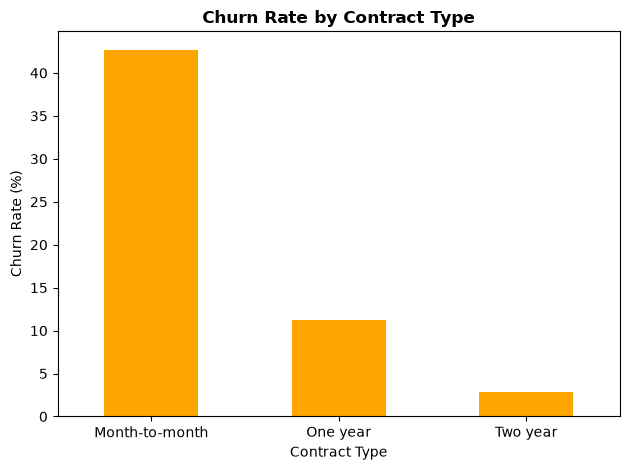

In [26]:
plt.figure()
churn_by_contract = (df.groupby('Contract')['has_churned'].mean() * 100).round(2)
churn_by_contract.plot(kind='bar', color='orange')
plt.title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('./results/01_churn_by_contract.png', dpi=300)
plt.show()

In [ ]:

churn_by_tenure_group = (df.groupby('tenure_group')['has_churned'].mean() * 100).round(2)
print(churn_by_tenure_group)
print(df.head())

tenure_group
0-3      56.21
4-6      44.63
7-9      37.27
10-12    34.34
13-24    28.71
25-50    20.25
50+       8.93
Name: has_churned, dtype: float64
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... StreamingTV  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...          No   
4           

tenure_group
0-3      56.21
4-6      44.63
7-9      37.27
10-12    34.34
13-24    28.71
25-50    20.25
50+       8.93
Name: has_churned, dtype: float64


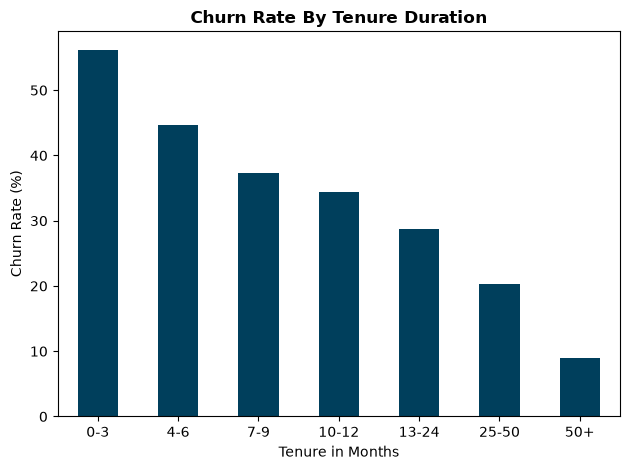

In [ ]:
# churn by tenure 
plt.figure()

churn_by_tenure_group = (df.groupby('tenure_group')['has_churned'].mean() * 100).round(2)
churn_by_tenure_group.plot(kind='bar', color="#003f5c")
plt.title("Churn Rate By Tenure Duration", fontsize=12, fontweight="bold")
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure in Months')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('./results/01_churn_by_contract.png', dpi=300)
print(churn_by_tenure_group)
